In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### Data Loading

Dataset : Medical Insurance Cost Prediction
Link:  https://www.kaggle.com/datasets/mirichoi0218/insurance

This dataset is used for regression

In [2]:
df = pd.read_csv('/content/insurance.csv')

display(df.head())

print(f"Dataset shape : {df.shape}")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset shape : (1338, 7)


### Data Preprocessing

In [3]:
# EDA
display(df.info())
display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [4]:
# missing value check and handle
display(df.isnull().sum())

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [5]:
# feature engineering

# categorize bmi
def cat_bmi(bmi):
  if bmi < 18.5:
    return 'Underweight'
  elif 18.5 <= bmi < 25:
    return 'Normal'
  elif 25 <= bmi < 30:
    return 'Overweight'
  else:
    return 'Obese'

df['bmi_category'] = df['bmi'].apply(cat_bmi)

# is parent or not
def is_par(children):
  if children > 0:
    return 1
  else:
    return 0

df['is_parent'] = df['children'].apply(is_par)

# Outlier handling capping bmi (Winsorization)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3.0 * IQR
upper_bound = Q3 + 3.0 * IQR

outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"Number of extreme outliers: {len(outliers)}")


Number of extreme outliers: 0


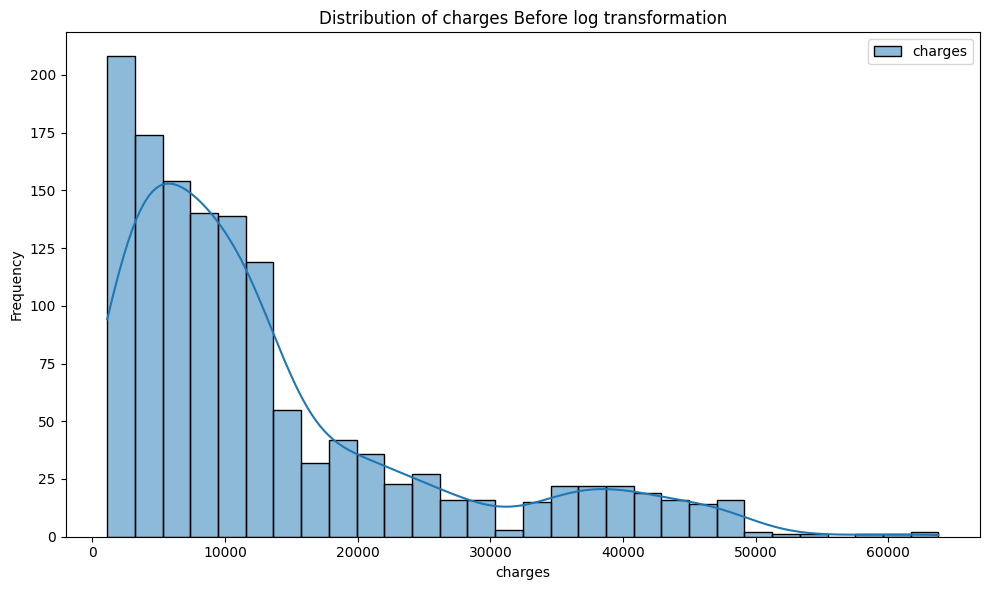

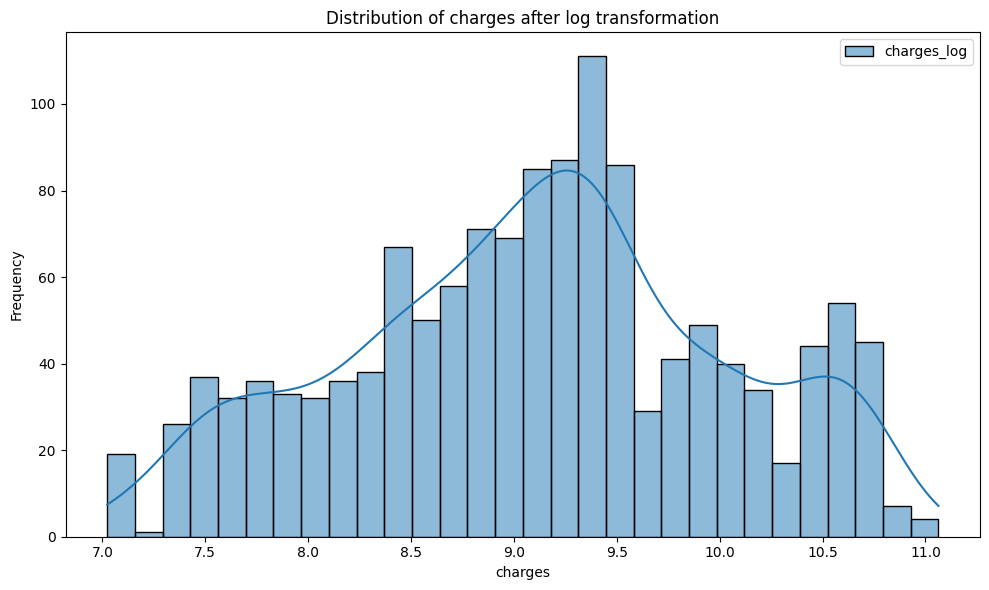

In [6]:
# since no extreme outliers found so winsorization is not applied above

# target column check
plt.figure(figsize=(10, 6))
sns.histplot(df[['charges']], bins=30, kde=True)
plt.title('Distribution of charges Before log transformation')
plt.xlabel('charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print()

# target column "charges" log transformation is applied to remove heavy skewness
df['charges_log'] = np.log1p(df['charges'])

plt.figure(figsize=(10, 6))
sns.histplot(df[['charges_log']], bins=30, kde=True)
plt.title('Distribution of charges after log transformation')
plt.xlabel('charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# display(df.head())

In [7]:
# feature x, y separation
X = df.drop(['charges', 'charges_log'], axis=1)
y = df['charges_log']

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Pipeline Creation

In [8]:
num_features =['age', 'bmi', 'children', 'is_parent']
cat_features = ['sex', 'smoker', 'region', 'bmi_category']

# numeric features process pipeline
num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

# categorical features process pipeline
cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

# combined preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

### Primary Model Selection

In [9]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor( random_state=42),
    'Gradient Boosting': GradientBoostingRegressor( random_state=42)
}

results=[]
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    cv_score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
      )
    rmse = np.sqrt(-cv_score).mean()
    results.append({'model': name, 'CV average rmse': rmse})

results_df = pd.DataFrame(results).sort_values(by='CV average rmse')
display(results_df)

,model,CV average rmse
2,Gradient Boosting,0.390329
1,Random Forest,0.396338
0,Linear Regression,0.451020


From the above result I selected Gradient Boosting regressor. Because it achieved the lowest crossvalidation rmse during the baseline testing. The model can successfully identify the complex nonlinear pattern from the dataset where other models mostly prone to high error rate.

### Model Training

In [10]:
final_gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# training
final_gb_pipeline.fit(X_train, y_train)
print("GB pipline train finished")

GB pipline train finished


### Cross-Validation

In [11]:
# apply 10 fold crossvalidation to gradient boosting regressor
cv_score = cross_val_score(
    final_gb_pipeline,
    X_train,
    y_train,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

cv_rmse = np.sqrt(-cv_score)

print("\n10-fold cross-validation results to check the model stability :\n")
print(f"CV RMSE: {cv_rmse}")
print(f"CV Average RMSE: {cv_rmse.mean():.4f}")
print(f"CV RMSE standard deviation: {cv_rmse.std():.4f}")


10-fold cross-validation results to check the model stability :

CV RMSE: [0.41440349 0.3872064  0.28043987 0.3268507  0.43462709 0.35089838
 0.44304519 0.37963558 0.3832063  0.43954567]
CV Average RMSE: 0.3840
CV RMSE standard deviation: 0.0502


### Hyperparameter Tuning

In [12]:
prams_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 4, 5]
}

# grid search to find best parameters within 10-folds
grid_search = GridSearchCV(
    final_gb_pipeline,
    prams_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1
  )

grid_search.fit(X_train, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV RMSE : {-grid_search.best_score_}")

Best parameters : {'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 300}
Best CV RMSE : 0.1450604860586871


### Best Model Selection

In [13]:
best_model = grid_search.best_estimator_
print(f"Best model : {best_model}")

Best model : Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children',
                                                   'is_parent']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle

### Model Performance Evaluation

Model Performance Evaluation :

MAE: 2074.48
MSE: 20346943.96
RMSE: 4510.76
R-squared: 0.87



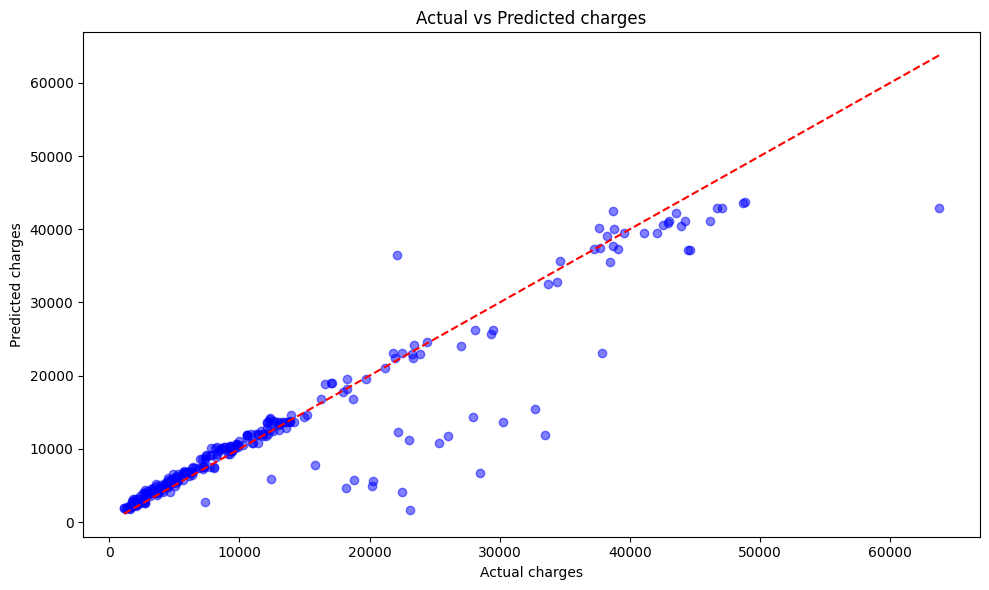

In [14]:
y_pred_log = best_model.predict(X_test)

# converting to actual values from log transformation applied on charges
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# evaluation metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print("Model Performance Evaluation :\n")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

print()
# actual vs predicted graph
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, color='blue')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], linestyle='--', color='red')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.title('Actual vs Predicted charges')
plt.tight_layout()
plt.show()

### saving the best trained model

In [16]:
import pickle

with open('best_GBR_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("model saving done")

model saving done


### check saved model

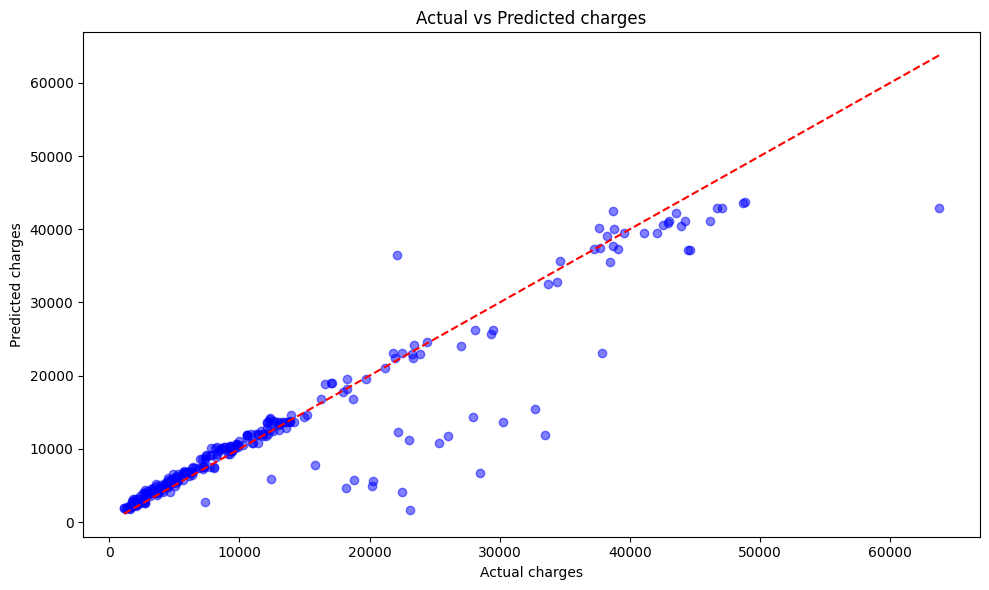

In [23]:
with open('/content/best_GBR_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

preds = loaded_model.predict(X_test)

preds = np.expm1(preds)
# print(np.expm1(preds))

# actual vs predicted graph
plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, preds, alpha=0.5, color='blue')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], linestyle='--', color='red')
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.title('Actual vs Predicted charges')
plt.tight_layout()
plt.show()